# NBD-Dirichlet 多カテゴリ分析：K × S マッピング

複数カテゴリに対して NBD モデルとディリクレ多項分布モデルを当てはめ、  
カテゴリごとの $K$（購入頻度の異質性）と $S$（ブランドロイヤルティ）を散布図上にマッピングする。

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import gammaln
from scipy.optimize import minimize
from scipy.stats import nbinom

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Hiragino Sans"

## Step 1: データ読み込み

In [11]:
DATA_DIR = "../data/dunnhumby"

df_trans = pd.read_csv(os.path.join(DATA_DIR, "transaction_data.csv"))
df_product = pd.read_csv(os.path.join(DATA_DIR, "product.csv"))

# 最初の52週間（DAY 1〜364）に絞る
min_day = df_trans["DAY"].min()
df_trans = df_trans[df_trans["DAY"] <= min_day + 7 * 52 - 1].copy()

df_trans = df_trans.merge(
    df_product[["PRODUCT_ID", "COMMODITY_DESC", "MANUFACTURER"]],
    on="PRODUCT_ID",
    how="left",
)

## Step 2: カテゴリ選定

以下の条件をすべて満たすカテゴリを分析対象とする。

- 購買世帯数 ≥ 200
- 主要メーカー（MANUFACTURER）が 3 以上
- 52週間の購買件数 ≥ 1,000

In [12]:
df_cat_stats = (
    df_trans.groupby("COMMODITY_DESC")
    .agg(
        n_households=("household_key", "nunique"),
        n_transactions=("BASKET_ID", "count"),
        n_manufacturers=("MANUFACTURER", "nunique"),
    )
    .reset_index()
)

df_categories = df_cat_stats[
    (df_cat_stats["n_households"] >= 200)
    & (df_cat_stats["n_manufacturers"] >= 3)
    & (df_cat_stats["n_transactions"] >= 1000)
].sort_values("n_transactions", ascending=False).reset_index(drop=True)

df_categories

,COMMODITY_DESC,n_households,n_transactions,n_manufacturers
0,SOFT DRINKS,2272,56090,33
1,FLUID MILK PRODUCTS,2288,39146,29
2,BAKED BREAD/BUNS/ROLLS,2269,37788,41
3,CHEESE,2167,33693,33
4,BAG SNACKS,2139,30676,42
...,...,...,...,...
165,MISCELLANEOUS,525,1079,12
166,VALUE ADDED VEGETABLES,433,1057,18
167,SPRING/SUMMER SEASONAL,580,1030,90
168,CHARCOAL AND LIGHTER FLUID,434,1016,15


In [13]:
# 分析対象カテゴリを選定（取引量上位かつメーカー数が多すぎないもの）
# メーカー数が多すぎると上位5+Othersの集約が粗くなるため、n_manufacturers <= 50 を目安にする
TARGET_CATEGORIES = [
    "SOFT DRINKS",
    "FLUID MILK PRODUCTS",
    "CHEESE",
    "BAG SNACKS",
    "COLD CEREAL",
    "YOGURT",
    "FROZEN PIZZA",
    "SOUP",
    "FRZN MEAT/MEAT DINNERS",
    "BAKED BREAD/BUNS/ROLLS",
]

print(f"分析対象カテゴリ: {len(TARGET_CATEGORIES)}")
for cat in TARGET_CATEGORIES:
    row = df_categories[df_categories["COMMODITY_DESC"] == cat]
    if len(row) > 0:
        r = row.iloc[0]
        print(f"  {cat}: {r['n_households']}世帯, {r['n_transactions']}件, {r['n_manufacturers']}メーカー")

分析対象カテゴリ: 10
  SOFT DRINKS: 2272世帯, 56090件, 33メーカー
  FLUID MILK PRODUCTS: 2288世帯, 39146件, 29メーカー
  CHEESE: 2167世帯, 33693件, 33メーカー
  BAG SNACKS: 2139世帯, 30676件, 42メーカー
  COLD CEREAL: 1839世帯, 17152件, 8メーカー
  YOGURT: 1423世帯, 20857件, 8メーカー
  FROZEN PIZZA: 1742世帯, 20772件, 35メーカー
  SOUP: 1878世帯, 20968件, 36メーカー
  FRZN MEAT/MEAT DINNERS: 1756世帯, 25334件, 38メーカー
  BAKED BREAD/BUNS/ROLLS: 2269世帯, 37788件, 41メーカー


## Step 3: カテゴリごとの NBD フィッティング

各カテゴリに対して、世帯ごとの購買回数を集計し、NBD の MLE で $(M, K)$ を推定する。

$$r_i \sim \mathrm{NegBin}(M, K), \quad \mathrm{Var}(r) = M + M^2/K$$

- $M$: 平均購買回数（プリファレンス）  
- $K$: 形状パラメータ（大きいほど消費者間の購買回数が均一）

In [14]:
def fit_nbd(counts):
    """NBD MLE: returns (K, M) where K=shape, M=mean."""
    mean_x = counts.mean()
    var_x = counts.var()
    p_init = mean_x / var_x if var_x > mean_x else 0.5
    r_init = max(mean_x * p_init / (1 - p_init + 1e-9), 0.1)

    def neg_loglik(params):
        r, p = params
        if r <= 0 or p <= 0 or p >= 1:
            return 1e10
        return -nbinom.logpmf(counts, n=r, p=p).sum()

    result = minimize(
        neg_loglik,
        x0=[r_init, p_init],
        method="Nelder-Mead",
        options={"maxiter": 10000},
    )
    r_hat, p_hat = result.x
    K = r_hat
    M = r_hat * (1 - p_hat) / p_hat
    return K, M, result.success

In [15]:
all_households = df_trans["household_key"].unique()

nbd_records = []
for cat in TARGET_CATEGORIES:
    df_cat = df_trans[df_trans["COMMODITY_DESC"] == cat]
    hh_counts = df_cat.groupby("household_key")["BASKET_ID"].count()
    # 購買していない世帯は0
    counts = hh_counts.reindex(all_households, fill_value=0).values

    K, M, converged = fit_nbd(counts)
    nbd_records.append({"category": cat, "M": M, "K": K, "converged": converged})
    print(f"{cat}: K={K:.3f}, M={M:.3f}, converged={converged}")

df_nbd = pd.DataFrame(nbd_records)
df_nbd

SOFT DRINKS: K=0.645, M=22.462, converged=True
FLUID MILK PRODUCTS: K=0.800, M=15.677, converged=True
CHEESE: K=0.686, M=13.493, converged=True
BAG SNACKS: K=0.649, M=12.285, converged=True
COLD CEREAL: K=0.499, M=6.869, converged=True
YOGURT: K=0.236, M=8.350, converged=True
FROZEN PIZZA: K=0.398, M=8.320, converged=True
SOUP: K=0.505, M=8.397, converged=True
FRZN MEAT/MEAT DINNERS: K=0.372, M=10.146, converged=True
BAKED BREAD/BUNS/ROLLS: K=0.784, M=15.133, converged=True


,category,M,K,converged
0,SOFT DRINKS,22.462237,0.645126,True
1,FLUID MILK PRODUCTS,15.677337,0.800004,True
2,CHEESE,13.492571,0.685921,True
3,BAG SNACKS,12.285095,0.648763,True
4,COLD CEREAL,6.868580,0.499048,True
5,YOGURT,8.349858,0.236459,True
6,FROZEN PIZZA,8.320064,0.397772,True
7,SOUP,8.397021,0.504716,True
8,FRZN MEAT/MEAT DINNERS,10.145871,0.371799,True
9,BAKED BREAD/BUNS/ROLLS,15.133163,0.783597,True


## Step 4: カテゴリごとのディリクレ多項分布フィッティング

各カテゴリについて、購買回数上位 5 MANUFACTURER + Others の 6 ブランドに集約し、  
ディリクレ多項分布の MLE で $\boldsymbol{\alpha}$ を推定、$S = \sum_j \alpha_j$ を算出する。

In [16]:
def dm_neg_loglik(log_alpha, X, n):
    """Negative log-likelihood of Dirichlet-Multinomial distribution."""
    alpha = np.exp(log_alpha)
    S = alpha.sum()
    N = len(n)
    ll = N * gammaln(S) - gammaln(n + S).sum()
    ll += (gammaln(X + alpha) - gammaln(alpha)).sum()
    return -ll


def fit_dm(df_cat):
    """Fit DM model for a category. Returns (alpha_hat, S_hat, brand_cols, converged)."""
    mfr_counts = df_cat["MANUFACTURER"].value_counts()
    top5 = mfr_counts.head(5).index.tolist()

    df_cat = df_cat.copy()
    df_cat["brand_group"] = df_cat["MANUFACTURER"].where(
        df_cat["MANUFACTURER"].isin(top5), other="Others"
    ).astype(str)
    labels = {str(m): f"Mfr_{m}" for m in top5}
    labels["Others"] = "Others"
    df_cat["brand_group"] = df_cat["brand_group"].map(labels)

    hh_brand = (
        df_cat.groupby(["household_key", "brand_group"])["BASKET_ID"]
        .count()
        .unstack(fill_value=0)
    )
    # 購買世帯のみ（少なくとも1回購買）
    hh_brand = hh_brand[hh_brand.sum(axis=1) > 0]

    brand_cols = hh_brand.columns.tolist()
    X = hh_brand.values.astype(float)
    n = X.sum(axis=1)
    J = len(brand_cols)

    share_init = X.sum(axis=0) / X.sum()
    alpha_init = share_init * J

    result = minimize(
        dm_neg_loglik,
        x0=np.log(alpha_init),
        args=(X, n),
        method="Nelder-Mead",
        options={"maxiter": 50000, "xatol": 1e-8, "fatol": 1e-8},
    )
    alpha_hat = np.exp(result.x)
    S_hat = alpha_hat.sum()
    return alpha_hat, S_hat, brand_cols, result.success

In [17]:
dm_records = []
for cat in TARGET_CATEGORIES:
    df_cat = df_trans[df_trans["COMMODITY_DESC"] == cat]
    _, S_hat, _, converged = fit_dm(df_cat)
    dm_records.append({"category": cat, "S": S_hat, "converged": converged})
    print(f"{cat}: S={S_hat:.3f}, converged={converged}")

df_dm = pd.DataFrame(dm_records)
df_dm

SOFT DRINKS: S=3.283, converged=True
FLUID MILK PRODUCTS: S=3.702, converged=True
CHEESE: S=5.739, converged=True
BAG SNACKS: S=5.476, converged=True
COLD CEREAL: S=3.486, converged=True
YOGURT: S=0.826, converged=True
FROZEN PIZZA: S=2.725, converged=True
SOUP: S=2.273, converged=True
FRZN MEAT/MEAT DINNERS: S=1.865, converged=True
BAKED BREAD/BUNS/ROLLS: S=3.520, converged=True


,category,S,converged
0,SOFT DRINKS,3.283300,True
1,FLUID MILK PRODUCTS,3.701882,True
2,CHEESE,5.739046,True
3,BAG SNACKS,5.476089,True
4,COLD CEREAL,3.485977,True
5,YOGURT,0.825675,True
6,FROZEN PIZZA,2.725303,True
7,SOUP,2.273119,True
8,FRZN MEAT/MEAT DINNERS,1.864719,True
9,BAKED BREAD/BUNS/ROLLS,3.520206,True


## Step 5: K × S マッピング

- x 軸: $K$（NBD 形状パラメータ）— 大きいほど消費者間の購買回数が均一
- y 軸: $S$（DM 集中度パラメータ）— 大きいほどブランドロイヤルティが高い

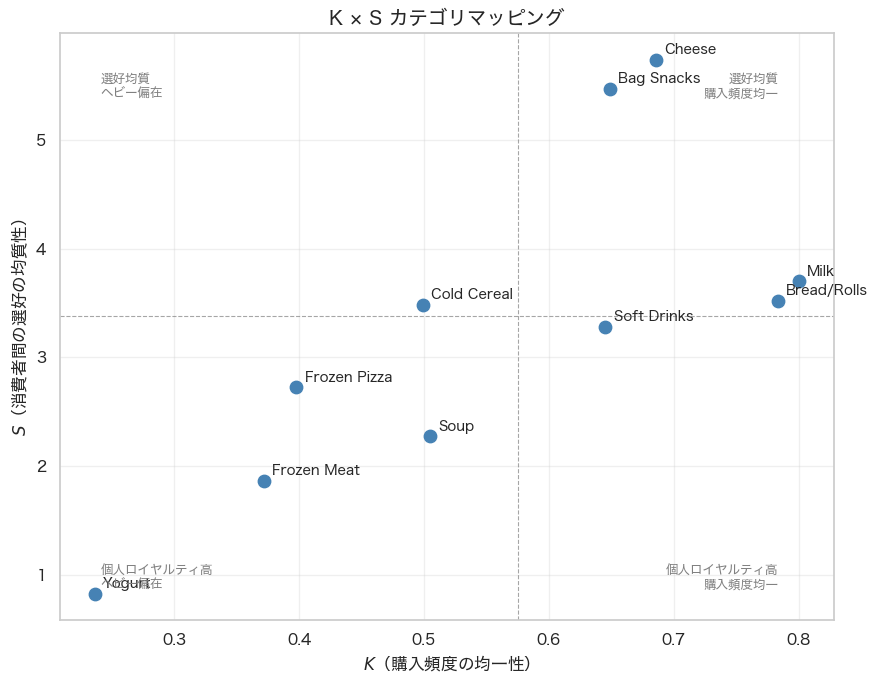

In [18]:
df_map = df_nbd[["category", "K"]].merge(df_dm[["category", "S"]], on="category")

# カテゴリ名を短縮してラベルを読みやすくする
short_labels = {
    "SOFT DRINKS": "Soft Drinks",
    "FLUID MILK PRODUCTS": "Milk",
    "CHEESE": "Cheese",
    "BAG SNACKS": "Bag Snacks",
    "COLD CEREAL": "Cold Cereal",
    "YOGURT": "Yogurt",
    "FROZEN PIZZA": "Frozen Pizza",
    "SOUP": "Soup",
    "FRZN MEAT/MEAT DINNERS": "Frozen Meat",
    "BAKED BREAD/BUNS/ROLLS": "Bread/Rolls",
}
df_map["label"] = df_map["category"].map(short_labels)

k_med = df_map["K"].median()
s_med = df_map["S"].median()

fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(df_map["K"], df_map["S"], s=80, color="steelblue", zorder=3)

for _, row in df_map.iterrows():
    ax.annotate(
        row["label"],
        xy=(row["K"], row["S"]),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=10,
    )

# 中央値で象限を区切る参照線
ax.axvline(k_med, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
ax.axhline(s_med, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

# 象限ラベル（S小=個人ロイヤルティ高、S大=選好均質）
ax.text(df_map["K"].max() * 0.98, df_map["S"].max() * 0.98,
        "選好均質\n購入頻度均一", ha="right", va="top", fontsize=9, color="gray")
ax.text(df_map["K"].min() * 1.02, df_map["S"].max() * 0.98,
        "選好均質\nヘビー偏在", ha="left", va="top", fontsize=9, color="gray")
ax.text(df_map["K"].max() * 0.98, df_map["S"].min() * 1.02,
        "個人ロイヤルティ高\n購入頻度均一", ha="right", va="bottom", fontsize=9, color="gray")
ax.text(df_map["K"].min() * 1.02, df_map["S"].min() * 1.02,
        "個人ロイヤルティ高\nヘビー偏在", ha="left", va="bottom", fontsize=9, color="gray")

ax.set_xlabel("$K$（購入頻度の均一性）", fontsize=12)
ax.set_ylabel("$S$（消費者間の選好の均質性）", fontsize=12)
ax.set_title("K × S カテゴリマッピング", fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../article/fig_ks_map.png", dpi=150, bbox_inches="tight")
plt.show()